# import libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load dataset

In [2]:
dataset=pd.read_csv(r"C:\Users\beher\OneDrive\Desktop\ML\student mark predictor\student_info.csv")

In [3]:
dataset.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [4]:
dataset.shape

(200, 2)

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [6]:
dataset.describe()

,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


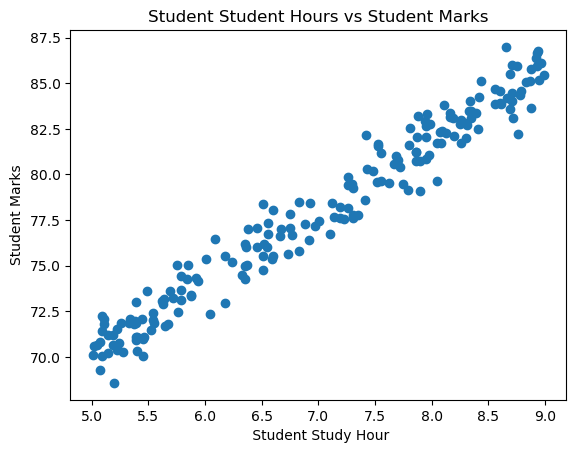

In [8]:
plt.scatter(x=dataset.study_hours,y=dataset.student_marks)
plt.xlabel(" Student Study Hour")
plt.ylabel("Student Marks")
plt.title("Student Student Hours vs Student Marks")
plt.show()

# data cleaning 

In [9]:
dataset.isnull().sum()

study_hours      5
student_marks    0
dtype: int64

In [10]:
dataset.mean()

study_hours       6.995949
student_marks    77.933750
dtype: float64

In [11]:
dataset2=dataset.fillna(dataset.mean())

In [14]:
dataset2.isna().sum()

study_hours      0
student_marks    0
dtype: int64

In [15]:
dataset2.head()

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19


# split the data 

In [16]:
x=dataset2[['study_hours']]
y=dataset2['student_marks']

In [17]:
print(x.shape)
print(y.shape)

(200, 1)
(200,)


In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)
print("shape x_train",x_train.shape)
print("shape x_test",x_test.shape)
print("shape y_train",y_train.shape)
print("shape y_test",x_test.shape)


shape x_train (160, 1)
shape x_test (40, 1)
shape y_train (160,)
shape y_test (40, 1)


# train the model

In [19]:
lr=LinearRegression()
lr.fit(x_train,y_train)


LinearRegression()

In [20]:
lr.coef_

array([3.93037294])

In [21]:
lr.intercept_

np.float64(50.450636324423726)

In [25]:
import warnings
warnings.filterwarnings('ignore')
lr.predict([[4]])

array([66.17212807])

In [26]:
y_pred=lr.predict(x_test)

In [29]:
y_pred

array([83.50507271, 70.84927186, 72.93236952, 85.35234799, 73.20749562,
       84.48766595, 80.12495199, 81.85431608, 80.91102657, 82.20804964,
       78.98514384, 84.84139951, 77.84533568, 77.68812077, 83.22994661,
       85.78468901, 84.9593107 , 72.61793968, 78.71001773, 79.18166248,
       84.2911473 , 85.6274741 , 74.74034107, 81.3433676 , 72.02838374,
       80.40007809, 78.98514384, 82.09013845, 77.94732382, 82.24735337,
       75.44780819, 84.60557713, 71.63534645, 75.48711192, 70.29901965,
       78.98514384, 75.32989701, 84.52696967, 74.07217767, 71.4388278 ])

In [31]:
pd.DataFrame(np.c_[x_test, y_test, y_pred], columns = ["study_hours", "student_marks_original","student_marks_predicted"])

,study_hours,student_marks_original,student_marks_predicted
0,8.410000,82.50,83.505073
1,5.190000,71.18,70.849272
2,5.720000,73.25,72.932370
3,8.880000,83.64,85.352348
4,5.790000,73.64,73.207496
5,8.660000,86.99,84.487666
6,7.550000,81.18,80.124952
7,7.990000,82.75,81.854316
8,7.750000,79.50,80.911027
9,8.080000,81.70,82.208050


# fine-tuning your model

In [32]:
lr.score(x_test,y_test)

0.9521841793508595

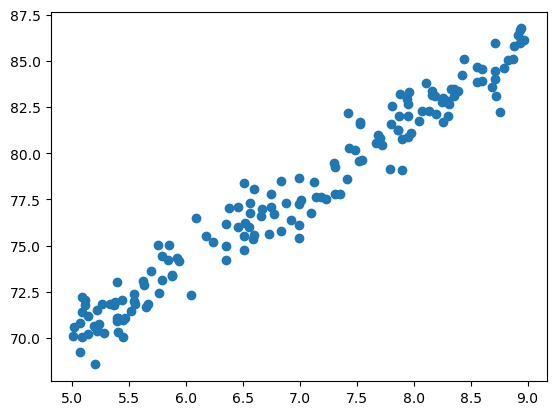

In [35]:
plt.scatter(x_train,y_train)
plt.show()